## 1. YOLO Training Setup

This notebook replaces the tiny bbox regressor with a stronger YOLO detector for license plate localization.

In [2]:
from pathlib import Path
import json
import random
import shutil
import xml.etree.ElementTree as ET

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import os

# ============ CUDA Detection and Setup ============
print("=" * 60)
print("CUDA Configuration")
print("=" * 60)

# Check CUDA availability
cuda_available = torch.cuda.is_available()
print(f"CUDA Available: {cuda_available}")
print(f"CUDA Version: {torch.version.cuda}")
print(f"cuDNN Version: {torch.backends.cudnn.version()}")
print(f"Number of GPUs: {torch.cuda.device_count()}")

if cuda_available:
    print(f"Current GPU: {torch.cuda.current_device()}")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB): {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print("⚠️  WARNING: CUDA not detected. Using CPU (training will be slow)")
    print("\nFix options:")
    print("1. Run: conda install pytorch torchvision torchaudio pytorch-cuda=12.1 -c pytorch -c nvidia")
    print("2. Or use pip: pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121")

# Set device
device = torch.device("cuda" if cuda_available else "cpu")
print(f"\nUsing device: {device}")
print("=" * 60)

try:
    from ultralytics import YOLO
except ImportError:
    import sys
    import subprocess
    print("\nInstalling ultralytics...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ultralytics"])
    from ultralytics import YOLO

CUDA Configuration
CUDA Available: True
CUDA Version: 12.1
cuDNN Version: 8907
Number of GPUs: 1
Current GPU: 0
GPU Name: NVIDIA GeForce RTX 2050
GPU Memory (GB): 4.29

Using device: cuda


In [3]:
SEED = 42
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

IMG_SIZE = 640
BATCH_SIZE = 16
EPOCHS = 80
BASE_MODEL = "yolov8s.pt"
RUN_NAME = "plate_yolov8s"

assert abs((TRAIN_RATIO + VAL_RATIO + TEST_RATIO) - 1.0) < 1e-8

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "ml").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing data/ and ml/")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
ANNOTATIONS_DIR = PROJECT_ROOT / "data" / "annotations"
IMAGES_DIR = PROJECT_ROOT / "data" / "images"
ARTIFACTS_DIR = PROJECT_ROOT / "ml" / "artifacts"
YOLO_DATASET_DIR = ARTIFACTS_DIR / "yolo_plate_dataset"
YOLO_RUNS_DIR = ARTIFACTS_DIR / "yolo_runs"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
YOLO_RUNS_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

train_device = 0 if torch.cuda.is_available() else "cpu"
print("Project root:", PROJECT_ROOT)
print("Train device:", train_device)
print("Annotations dir exists:", ANNOTATIONS_DIR.exists())
print("Images dir exists:", IMAGES_DIR.exists())

Project root: C:\Users\bristimaharjan\Downloads\License\Isurance
Train device: 0
Annotations dir exists: True
Images dir exists: True


## 2. Parse Pascal VOC XML

Convert XML records to normalized `xyxy` boxes.

In [4]:
def parse_xml_record(xml_path: Path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.findtext("filename")
    size = root.find("size")
    if filename is None or size is None:
        return None

    width = float(size.findtext("width"))
    height = float(size.findtext("height"))
    if width <= 0 or height <= 0:
        return None

    image_path = IMAGES_DIR / filename
    if not image_path.exists():
        return None

    boxes = []
    for obj in root.findall("object"):
        bbox = obj.find("bndbox")
        if bbox is None:
            continue

        xmin = max(0.0, min(1.0, float(bbox.findtext("xmin")) / width))
        ymin = max(0.0, min(1.0, float(bbox.findtext("ymin")) / height))
        xmax = max(0.0, min(1.0, float(bbox.findtext("xmax")) / width))
        ymax = max(0.0, min(1.0, float(bbox.findtext("ymax")) / height))

        if xmax <= xmin or ymax <= ymin:
            continue
        boxes.append([xmin, ymin, xmax, ymax])

    if not boxes:
        return None

    return {
        "image_path": str(image_path),
        "boxes": boxes,
        "width": int(width),
        "height": int(height),
        "xml": str(xml_path)
    }


records = []
for xml_path in sorted(ANNOTATIONS_DIR.glob("*.xml")):
    rec = parse_xml_record(xml_path)
    if rec is not None:
        records.append(rec)

print(f"Valid images with boxes: {len(records)}")
print("First record:", records[0] if records else "No samples found")

Valid images with boxes: 433
First record: {'image_path': 'C:\\Users\\bristimaharjan\\Downloads\\License\\Isurance\\data\\images\\Cars0.png', 'boxes': [[0.452, 0.4664179104477612, 0.838, 0.6455223880597015]], 'width': 500, 'height': 268, 'xml': 'C:\\Users\\bristimaharjan\\Downloads\\License\\Isurance\\data\\annotations\\Cars0.xml'}


In [5]:
indices = np.arange(len(records))
rng = np.random.default_rng(SEED)
rng.shuffle(indices)

n_total = len(indices)
n_train = int(n_total * TRAIN_RATIO)
n_val = int(n_total * VAL_RATIO)

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

train_records = [records[i] for i in train_idx]
val_records = [records[i] for i in val_idx]
test_records = [records[i] for i in test_idx]

print(f"Total: {n_total}")
print(f"Train: {len(train_records)}")
print(f"Validation: {len(val_records)}")
print(f"Test: {len(test_records)}")

Total: 433
Train: 303
Validation: 64
Test: 66


## 3. Convert to YOLO Format

Write `images/{split}` and `labels/{split}` plus `dataset.yaml`.

In [6]:
def to_yolo_line(box_xyxy):
    xmin, ymin, xmax, ymax = box_xyxy
    bw = xmax - xmin
    bh = ymax - ymin
    xc = xmin + bw / 2
    yc = ymin + bh / 2
    return xc, yc, bw, bh


def build_yolo_dataset(root_dir: Path, train_items, val_items, test_items):
    if root_dir.exists():
        shutil.rmtree(root_dir)

    for split in ["train", "val", "test"]:
        (root_dir / "images" / split).mkdir(parents=True, exist_ok=True)
        (root_dir / "labels" / split).mkdir(parents=True, exist_ok=True)

    split_map = {
        "train": train_items,
        "val": val_items,
        "test": test_items
    }

    summary = {}
    for split, items in split_map.items():
        written = 0
        for item in items:
            src_img = Path(item["image_path"])
            dst_img = root_dir / "images" / split / src_img.name
            shutil.copy2(src_img, dst_img)

            label_path = root_dir / "labels" / split / f"{src_img.stem}.txt"
            yolo_lines = []
            for box in item["boxes"]:
                xc, yc, bw, bh = to_yolo_line(box)
                if bw <= 0 or bh <= 0:
                    continue
                yolo_lines.append(f"0 {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")

            with open(label_path, "w", encoding="utf-8") as f:
                f.write("\n".join(yolo_lines))

            written += 1

        summary[split] = written

    dataset_yaml = root_dir / "dataset.yaml"
    yaml_text = [
        f"path: {root_dir.as_posix()}",
        "train: images/train",
        "val: images/val",
        "test: images/test",
        "",
        "names:",
        "  0: plate"
    ]
    with open(dataset_yaml, "w", encoding="utf-8") as f:
        f.write("\n".join(yaml_text) + "\n")

    return dataset_yaml, summary


data_yaml, split_summary = build_yolo_dataset(
    YOLO_DATASET_DIR,
    train_records,
    val_records,
    test_records
)

print("YOLO dataset dir:", YOLO_DATASET_DIR)
print("Dataset yaml:", data_yaml)
print("Split summary:", split_summary)

YOLO dataset dir: C:\Users\bristimaharjan\Downloads\License\Isurance\ml\artifacts\yolo_plate_dataset
Dataset yaml: C:\Users\bristimaharjan\Downloads\License\Isurance\ml\artifacts\yolo_plate_dataset\dataset.yaml
Split summary: {'train': 303, 'val': 64, 'test': 66}


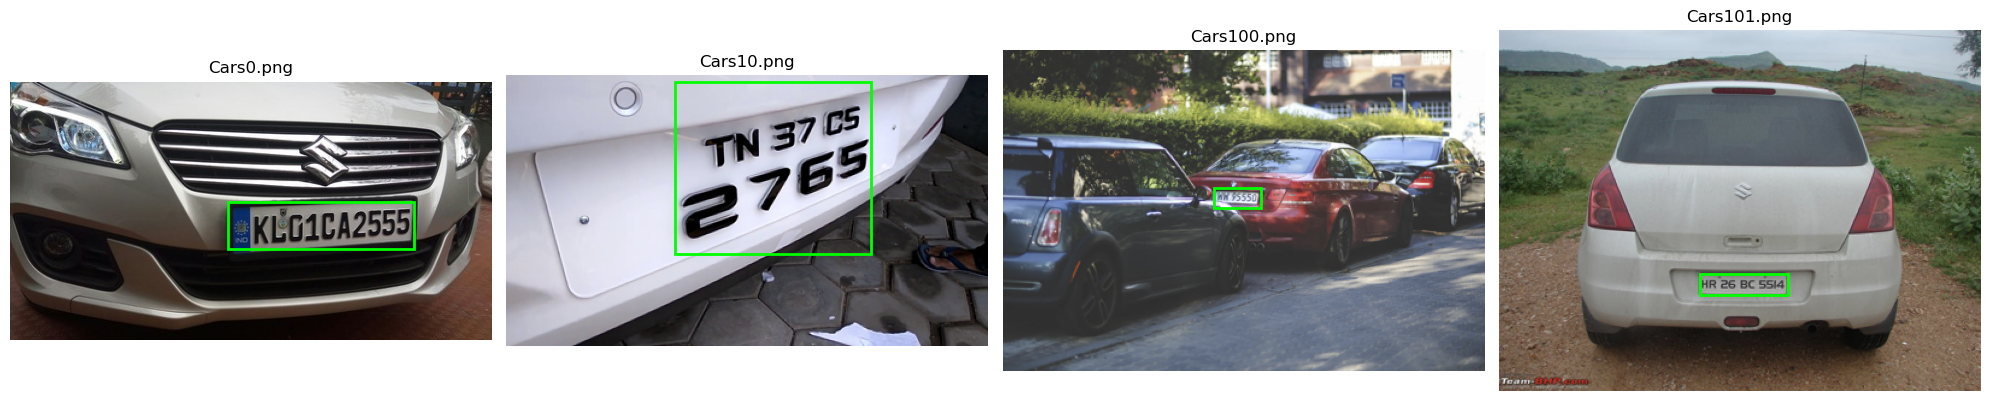

In [7]:
def plot_labeled_samples(yolo_root: Path, split="train", n=4):
    image_paths = sorted((yolo_root / "images" / split).glob("*"))[:n]
    if not image_paths:
        print("No images found for split:", split)
        return

    fig, axes = plt.subplots(1, len(image_paths), figsize=(5 * len(image_paths), 4))
    axes = np.array(axes).reshape(-1)

    for ax, img_path in zip(axes, image_paths):
        img = Image.open(img_path).convert("RGB")
        img_np = np.array(img)
        h, w = img_np.shape[:2]
        ax.imshow(img_np)

        label_path = yolo_root / "labels" / split / f"{img_path.stem}.txt"
        if label_path.exists():
            for line in label_path.read_text(encoding="utf-8").splitlines():
                cls_id, xc, yc, bw, bh = line.split()
                xc, yc, bw, bh = map(float, (xc, yc, bw, bh))
                x0 = (xc - bw / 2) * w
                y0 = (yc - bh / 2) * h
                rect = plt.Rectangle((x0, y0), bw * w, bh * h, fill=False, color="lime", linewidth=2)
                ax.add_patch(rect)

        ax.set_title(img_path.name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


plot_labeled_samples(YOLO_DATASET_DIR, split="train", n=4)

## 4. Train YOLO



In [8]:
model = YOLO(BASE_MODEL)
train_results = model.train(
    data=str(data_yaml),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=train_device,
    project=str(YOLO_RUNS_DIR),
    name=RUN_NAME,
    exist_ok=True,
    seed=SEED,
    workers=0
)

run_dir = Path(model.trainer.save_dir)
best_weights = run_dir / "weights" / "best.pt"
print("Run dir:", run_dir)
print("Best weights:", best_weights)

Ultralytics 8.4.37  Python-3.11.15 torch-2.3.1 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\bristimaharjan\Downloads\License\Isurance\ml\artifacts\yolo_plate_dataset\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plate_yolov8s, nbs=64, nms=False, 

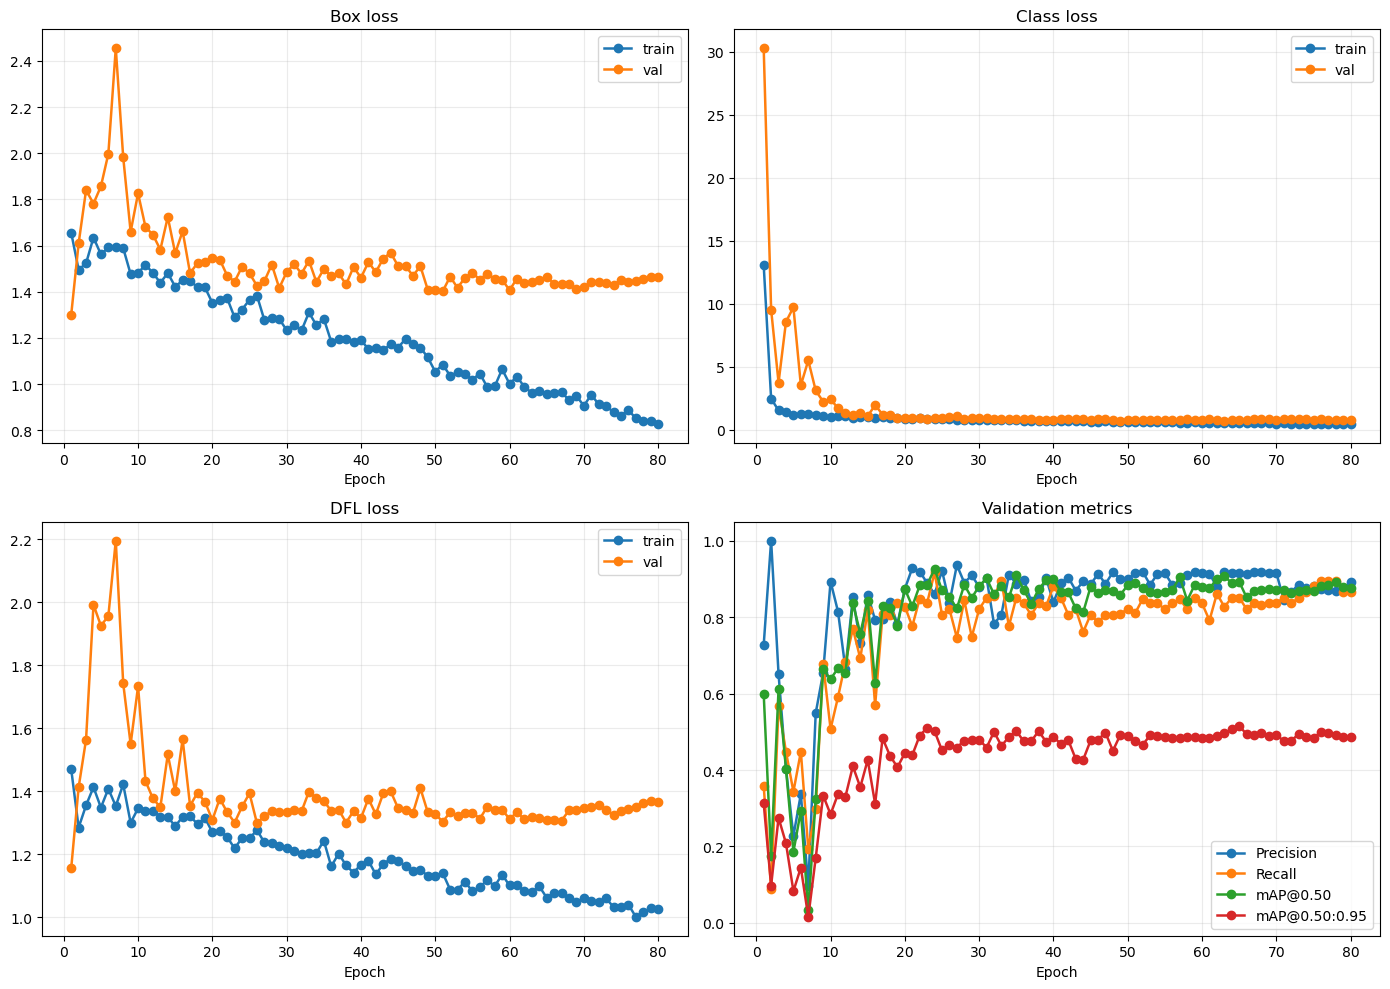

Plotted from: C:\Users\bristimaharjan\Downloads\License\Isurance\ml\artifacts\yolo_runs\plate_yolov8s\results.csv


In [9]:
import csv

results_csv = run_dir / "results.csv"
if not results_csv.exists():
    raise FileNotFoundError(f"Could not find YOLO training log: {results_csv}")

with open(results_csv, "r", encoding="utf-8", newline="") as f:
    rows = list(csv.DictReader(f))

if not rows:
    raise ValueError(f"No rows found in {results_csv}")

columns = [c.strip() for c in rows[0].keys() if c is not None]

# Build a numeric series map from CSV columns while ignoring blanks/non-numeric values.
series = {}
for col in columns:
    values = []
    for row in rows:
        raw = (row.get(col) or "").strip()
        if raw == "":
            values.append(np.nan)
        else:
            try:
                values.append(float(raw))
            except ValueError:
                values.append(np.nan)
    arr = np.array(values, dtype=float)
    if np.isfinite(arr).any():
        series[col] = arr

if "epoch" in series:
    epochs = series["epoch"]
else:
    epochs = np.arange(len(rows), dtype=float)

def pick_existing(series_map, candidates):
    for c in candidates:
        if c in series_map:
            return c
    return None

loss_specs = [
    ("Box loss", ["train/box_loss"], ["val/box_loss"]),
    ("Class loss", ["train/cls_loss"], ["val/cls_loss"]),
    ("DFL loss", ["train/dfl_loss"], ["val/dfl_loss"]),
]

metric_specs = [
    ("Precision", ["metrics/precision(B)"]),
    ("Recall", ["metrics/recall(B)"]),
    ("mAP@0.50", ["metrics/mAP50(B)"]),
    ("mAP@0.50:0.95", ["metrics/mAP50-95(B)"]),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (title, train_candidates, val_candidates) in enumerate(loss_specs):
    ax = axes[i]
    train_col = pick_existing(series, train_candidates)
    val_col = pick_existing(series, val_candidates)

    if train_col is not None:
        ax.plot(epochs, series[train_col], marker="o", linewidth=1.8, label="train")
    if val_col is not None:
        ax.plot(epochs, series[val_col], marker="o", linewidth=1.8, label="val")

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.25)
    ax.legend()

ax = axes[3]
for title, candidates in metric_specs:
    col = pick_existing(series, candidates)
    if col is not None:
        ax.plot(epochs, series[col], marker="o", linewidth=1.8, label=title)

ax.set_title("Validation metrics")
ax.set_xlabel("Epoch")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

print("Plotted from:", results_csv)

## 5. Validate on Test Split

In [10]:
best_model = YOLO(str(best_weights))
val_metrics = best_model.val(data=str(data_yaml), split="test", imgsz=IMG_SIZE, device=train_device)

metrics = {
    "test_map50": float(val_metrics.box.map50),
    "test_map50_95": float(val_metrics.box.map),
    "test_precision": float(val_metrics.box.mp),
    "test_recall": float(val_metrics.box.mr)
}

print(json.dumps(metrics, indent=2))

Ultralytics 8.4.37  Python-3.11.15 torch-2.3.1 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.50.1 ms, read: 28.011.0 MB/s, size: 376.9 KB)
val: Scanning C:\Users\bristimaharjan\Downloads\License\Isurance\ml\artifacts\yolo_plate_dataset\labels\test... 66 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 66/66 196.4it/s 0.3s.3s
val: New cache created: C:\Users\bristimaharjan\Downloads\License\Isurance\ml\artifacts\yolo_plate_dataset\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 20% ━━────────── 1/5 64.5s/it 19.4s<4:18

Exception in thread Thread-51 (plot_images):
Traceback (most recent call last):
  File "c:\Users\bristimaharjan\.conda\envs\isurance-ml-cuda\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\bristimaharjan\.conda\envs\isurance-ml-cuda\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\bristimaharjan\.conda\envs\isurance-ml-cuda\Lib\site-packages\ultralytics\utils\plotting.py", line 751, in plot_images
    mosaic = np.full((int(ns * h), int(ns * w), 3), 255, dtype=np.uint8)  # init
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\bristimaharjan\.conda\envs\isurance-ml-cuda\Lib\site-packages\numpy\_core\numeric.py", line 385, in full
    a = empty(shape, dtype, order, device=device)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
numpy._core._exceptions._ArrayMemoryError: Unable to allocate 11.8 MiB for an array with shape (1536, 2688, 3) and data type uint8


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 20% ━━────────── 1/5 92.2s/it 21.1s<6:09


OutOfMemoryError: CUDA out of memory. Tried to allocate 74.00 MiB. GPU 

In [ ]:
def show_predictions(model_obj, yolo_root: Path, split="test", n=6, conf=0.25):
    image_paths = sorted((yolo_root / "images" / split).glob("*"))[:n]
    if not image_paths:
        print("No images available for prediction preview")
        return

    preds = model_obj.predict(
        source=[str(p) for p in image_paths],
        imgsz=IMG_SIZE,
        conf=conf,
        device=train_device,
        verbose=False
    )

    cols = 3
    rows = int(np.ceil(len(preds) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for i, pred in enumerate(preds):
        ax = axes[i]

        # Prefer Ultralytics in-memory image to avoid temp-name path issues like image0.jpg.
        if getattr(pred, "orig_img", None) is not None:
            img = pred.orig_img[..., ::-1]
            title_name = Path(image_paths[i]).name
        else:
            fallback_path = image_paths[i]
            img = np.array(Image.open(fallback_path).convert("RGB"))
            title_name = fallback_path.name

        ax.imshow(img)

        if pred.boxes is not None and len(pred.boxes) > 0:
            for box, score in zip(pred.boxes.xyxy.cpu().numpy(), pred.boxes.conf.cpu().numpy()):
                x1, y1, x2, y2 = box
                rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color="red", linewidth=2)
                ax.add_patch(rect)
                ax.text(x1, max(0, y1 - 5), f"plate {score:.2f}", color="yellow", fontsize=9, bbox={"facecolor": "black", "alpha": 0.5, "pad": 1})

        ax.set_title(title_name)

    plt.tight_layout()
    plt.show()


show_predictions(best_model, YOLO_DATASET_DIR, split="test", n=6, conf=0.25)

## 6. Export Backend-Ready Artifacts

Exports:
- `plate_bbox_yolo_best.pt` (best YOLO weights)
- `plate_bbox_yolo_best.onnx` (ONNX export)
- `plate_bbox_yolo_metrics.json` (test metrics + config)

In [ ]:
best_export_path = ARTIFACTS_DIR / "plate_bbox_yolo_best.pt"
shutil.copy2(best_weights, best_export_path)

onnx_result = best_model.export(format="onnx", imgsz=IMG_SIZE)
onnx_path = Path(onnx_result)
onnx_export_path = ARTIFACTS_DIR / "plate_bbox_yolo_best.onnx"
shutil.copy2(onnx_path, onnx_export_path)

payload = {
    "model_name": BASE_MODEL,
    "run_name": RUN_NAME,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "splits": split_summary,
    "classes": ["plate"],
    "metrics": metrics,
    "dataset_yaml": str(data_yaml),
    "run_dir": str(run_dir)
}

metrics_path = ARTIFACTS_DIR / "plate_bbox_yolo_metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2)

print("Saved:")
print("-", best_export_path)
print("-", onnx_export_path)
print("-", metrics_path)